# 옷 개기

### 현재 연결 상태

In [ ]:
from IPython.core.display import Markdown, HTML
display(Markdown("[현재 기기 연결 상태]"), display_id="device_state")
display(HTML(""), display_id="device_state_errors")
display(HTML(""), display_id="motor_server_state");


> ⛔ 장비 초기화 완료

- **Follower**: ⛔ 연결 실패 (`ConnectionError('Failed to open OpenCVCamera(/dev/lerobot/camera_2).Run `lerobot-find-cameras opencv` to find available cameras.')`)
  - 왼팔: `/dev/lerobot/follower_1`
  - 오른팔: `/dev/lerobot/follower_2`
  - 전경 카메라: `/dev/lerobot/camera_0`
  - 왼팔 카메라: `/dev/lerobot/camera_1`
  - 오른팔 카메라: `/dev/lerobot/camera_2`
- **Leader**: ✅ **연결됨**
  - Left Arm: `/dev/lerobot/leader_1`
  - Right Arm: `/dev/lerobot/leader_2`
    

## 기본 초기화

### 코드 헤더

In [2]:
import time
import sys
from types import SimpleNamespace
from pathlib import Path
import traceback
from IPython.core.display import Markdown
import ipywidgets as widgets

display(Markdown("> 🚧 **코드 초기화 중**"), display_id="device_state", update=True);

In [ ]:
import lerobot
from lerobot.policies.diffusion.modeling_diffusion import DiffusionPolicy
from lerobot.policies.diffusion.configuration_diffusion import DiffusionConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata

from lerobot.robots.so_follower import SO101FollowerConfig
from lerobot.robots.so_follower.config_so_follower import SOFollowerConfig
from lerobot.robots.bi_so_follower import BiSOFollower, BiSOFollowerConfig
from lerobot.teleoperators.so_leader import SO101LeaderConfig
from lerobot.teleoperators.so_leader.config_so_leader import SOLeaderConfig

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from lerobot.teleoperators.bi_so_leader import BiSOLeader

# try:
#     from common.remote_bi_so_leader import RemoteBiSOLeader as BiSOLeader
#     print("remote bi_so_leader 사용")
# except ImportError:
#     from lerobot.teleoperators.bi_so_leader import BiSOLeader
#     print("local bi_so_leader 사용")
from lerobot.teleoperators.bi_so_leader import BiSOLeaderConfig

from lerobot.processor import make_default_processors

import cv2

### 장비 초기화

In [4]:
import traceback
from IPython.core.getipython import get_ipython
from IPython.display import display, update_display, TextDisplayObject

teleop_action_processor = None
robot_action_processor = None
robot_observation_processor = None
robot: BiSOFollower
leader: BiSOLeader

accumulated_error_for_creating_setup = []

def simple_error(e: Exception) -> str:
    accumulated_error_for_creating_setup.append(e)
    return f"`{repr(e)}`"

def create_error_trace(e: Exception):
    shell = get_ipython()
    etype, evalue, tb = sys.exc_info()
    
    formatted_tb = shell.InteractiveTB.structured_traceback(etype, evalue, tb)
    traceback_text = shell.InteractiveTB.stb2text(formatted_tb)
    return TextDisplayObject(traceback_text)


def update_device_state_load(message, robot_state, leader_state):
    content = Markdown(f"""
{message}

- **Follower**: {"..." if robot_state is None else robot_state}
  - 왼팔: `{robot_config.left_arm_config.port}`
  - 오른팔: `{robot_config.right_arm_config.port}`
  - 전경 카메라: `{robot_config.cameras['top'].index_or_path}`
  - 왼팔 카메라: `{robot_config.left_arm_config.cameras['cam'].index_or_path}`
  - 오른팔 카메라: `{robot_config.right_arm_config.cameras['cam'].index_or_path}`
- **Leader**: {"..." if leader_state is None else leader_state}
  - Left Arm: `{leader_config.left_arm_config.port}`
  - Right Arm: `{leader_config.right_arm_config.port}`
    """)
    display(content, display_id="device_state", update=True)

def setup_devices(initialize = True):
    global teleop_action_processor, robot_action_processor, robot_observation_processor, robot, leader
    global accumulated_error_for_creating_setup
    global streamer

    accumulated_error_for_creating_setup = []

    robot_state = None
    leader_state = None

    update_device_state_load("> 🚧 **장비 초기화 중**", robot_state, leader_state)

    if "robot" in globals() and robot is not None and robot.is_connected:
        try: robot.disconnect()
        except: pass
    if "leader" in globals() and leader is not None and leader.is_connected:
        try: leader.disconnect()
        except: pass

    update_device_state_load("> 🚧 **장비 초기화 중** (1/4)", robot_state, leader_state)

    try:
        from camera_streamer import CameraStreamer
        streamer = CameraStreamer()
        streamer.stop_all_captures()
        streamer.start_server()
        print(f"Camera Stream URL: {streamer.get_server_url()}")
    except Exception as e:
        print(f"Failed to start camera streamer: {e}")

    update_device_state_load("> 🚧 **장비 초기화 중** (2/4)", robot_state, leader_state)

    teleop_action_processor, robot_action_processor, robot_observation_processor = make_default_processors()

    try:
        robot = BiSOFollower(robot_config)
        robot.connect()
        print(f"connected to follower arms: left on {robot_config.left_arm_config.port}, right on {robot_config.right_arm_config.port}")
    except Exception as e:
        robot_state = f"⛔ 연결 실패 ({simple_error(e)})"
        traceback.print_exception(e)
    
    if robot_state is None:
        try:
            robot_state = "✅ **연결됨**" if "robot" in globals() and robot is not None and robot.is_connected and robot.is_calibrated else "⛔ **연결 안됨**"
        except Exception as e:
            robot_state = f"⛔ 상태를 불러오지 못함 ({simple_error(e)})"
            traceback.print_exception(e)

    update_device_state_load("> 🚧 **장비 초기화 중** (3/4)", robot_state, leader_state)

    try:
        leader = BiSOLeader(leader_config)
        leader.connect()
        print(f"connected to leader arms: left on {leader_config.left_arm_config.port}, right on {leader_config.right_arm_config.port}")
    except Exception as e:
        leader_state = f"⛔ 연결 실패 ({simple_error(e)})"
        traceback.print_exception(e)

    if leader_state is None:
        try:
            leader_state = "✅ **연결됨**" if "leader" in globals() and leader is not None and leader.is_connected else "⛔ **연결 안됨**"
        except Exception as e:
            leader_state = f"⛔ 상태를 불러오지 못함 ({simple_error(e)})"
            traceback.print_exception(e)

    update_device_state_load(f"> {"✅" if len(accumulated_error_for_creating_setup) == 0 else "⛔"} 장비 초기화 완료", robot_state, leader_state)

    views: list[widgets.Widget] = []

    for e in accumulated_error_for_creating_setup:
        trace = widgets.Output()
        with trace:
            traceback.print_exception(e)
        views.append(widgets.Accordion(children=[trace], titles=["예외"]))
    
    display(widgets.HBox(children=views), display_id="device_state_errors", update=True)

### 서버 상태 보기

In [5]:
import threading
import time
import socket
import json

log_output = widgets.Output(layout={'border': '1px solid #ccc', 'width': '100%', 'height': '100px', 'overflow_y': 'auto'})
status_label = widgets.HTML(value="<b>Status:</b> Initializing...")
left_label = widgets.HTML(value="<b>Left Arm Raw:</b> -")
right_label = widgets.HTML(value="<b>Right Arm Raw:</b> -")

start_btn = widgets.Button(description="Start Server", button_style="success", icon="play")
stop_btn = widgets.Button(description="Stop Server", button_style="danger", icon="stop")
clear_btn = widgets.Button(description="Clear Logs", button_style="warning", icon="trash")

controls = widgets.HBox([start_btn, stop_btn, clear_btn])
display_box = widgets.VBox([
    widgets.HTML("<h3>📡 Remote Leader UDP Server Manager</h3>"),
    status_label,
    widgets.VBox([
        left_label,
        right_label,
    ], layout={'gap': '0'}),
    controls,
])
log_box = widgets.VBox([
    widgets.HTML("<br/><b>Live Server Logs:</b>"),
    log_output
], layout={'flex': '1'})
display_box = widgets.HBox([display_box, log_box], layout={'gap': '30px'})

monitor_running = True
temp_sock = None
temp_thread = None
temp_stop = threading.Event()
temp_latest = {"left": None, "right": None}

def add_log(msg):
    with log_output:
        print(f"[{time.strftime('%H:%M:%S')}] {msg}")
def check_leader_status():
    leader_inst = globals().get('leader')
    if leader_inst and getattr(leader_inst, '_connected', False):
        return "leader_running"
    elif temp_sock is not None:
        return "temp_running"
    return "stopped"

def update_gui():
    state = check_leader_status()
    if state == "leader_running":
        leader_inst = globals().get('leader')
        status_label.value = f"<b>Status:</b> 🟢 RUNNING (via global <code>leader</code> object on port {leader_inst.port})"
        start_btn.disabled = True
        stop_btn.disabled = False
        with leader_inst.lock:
            left_label.value = f"<b>Left Arm:</b> {leader_inst.latest_raw_left}"
            right_label.value = f"<b>Right Arm:</b> {leader_inst.latest_raw_right}"
    elif state == "temp_running":
        status_label.value = "<b>Status:</b> 🟡 RUNNING (Standalone test server on port 5005)"
        start_btn.disabled = True
        stop_btn.disabled = False
        left_label.value = f"<b>Left Arm:</b> {temp_latest['left']}"
        right_label.value = f"<b>Right Arm:</b> {temp_latest['right']}"
    else:
        status_label.value = "<b>Status:</b> 🔴 STOPPED"
        start_btn.disabled = False
        stop_btn.disabled = True
        left_label.value = "<b>Left Arm:</b> -"
        right_label.value = "<b>Right Arm:</b> -"

def start_server_clicked(b):
    leader_inst = globals().get('leader')
    if leader_inst:
        try:
            leader_inst.connect()
            add_log("Started notebook leader server.")
        except Exception as e:
            add_log(f"Error starting leader server: {e}")
    else:
        # Start standalone server for testing
        global temp_sock, temp_thread
        temp_stop.clear()
        try:
            temp_sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            temp_sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            temp_sock.bind(("0.0.0.0", 5005))
            temp_sock.settimeout(0.5)
            
            def recv_loop():
                add_log("Standalone UDP test receiver started on port 5005.")
                packet_count = 0
                while not temp_stop.is_set():
                    try:
                        data, addr = temp_sock.recvfrom(4096)
                        payload = json.loads(data.decode("utf-8"))
                        pkt_type = payload.get("type")
                        if pkt_type == "calibration":
                            add_log(f"Handshake: Received calibration from {addr}")
                        elif pkt_type == "positions":
                            packet_count += 1
                            if "left" in payload:
                                temp_latest["left"] = payload["left"]
                            if "right" in payload:
                                temp_latest["right"] = payload["right"]
                            if packet_count % 150 == 0:
                                add_log(f"Stream: Received {packet_count} position packets.")
                    except socket.timeout:
                        continue
                    except Exception as e:
                        add_log(f"Test server loop error: {e}")
                        break
                add_log("Standalone test receiver stopped.")
                
            temp_thread = threading.Thread(target=recv_loop, daemon=True)
            temp_thread.start()
        except Exception as e:
            add_log(f"Failed to bind socket: {e}")
            temp_sock = None
    update_gui()

def stop_server_clicked(b):
    leader_inst = globals().get('leader')
    if leader_inst and getattr(leader_inst, '_connected', False):
        leader_inst.disconnect()
        add_log("Stopped notebook leader server.")
    
    global temp_sock
    if temp_sock is not None:
        temp_stop.set()
        temp_sock.close()
        if temp_thread:
            temp_thread.join(timeout=1.0)
        temp_sock = None
        add_log("Stopped standalone test server.")
    update_gui()
def clear_logs_clicked(b):
    log_output.clear_output()

start_btn.on_click(start_server_clicked)
stop_btn.on_click(stop_server_clicked)
clear_btn.on_click(clear_logs_clicked)

display(display_box)

def gui_update_loop():
    while monitor_running:
        try:
            update_gui()
        except Exception:
            pass
        time.sleep(0.5)
        
monitor_thread = threading.Thread(target=gui_update_loop, daemon=True)
monitor_thread.start()

if check_leader_status() == "stopped":
    start_server_clicked(None)

### 외부장비 설정

In [ ]:
from lerobot.cameras.opencv import OpenCVCameraConfig

left_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_1",
    fps=30,
    width=160,
    height=120,
    fourcc="MJPG",
)
right_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_2",
    fps=30,
    width=160,
    height=120,
    fourcc="MJPG",
)
top_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_0",
    fps=30,
    width=640,
    height=480,
    fourcc="MJPG",
)

left_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_1",
    cameras={"cam": left_cam_config},
)
right_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_2",
    cameras={"cam": right_cam_config},
)

robot_config = BiSOFollowerConfig(
    id="lhwdev_follower_bimanual",
    left_arm_config=left_follower_config,
    right_arm_config=right_follower_config,
    cameras={"top": top_cam_config},
)

# Configure leader
left_leader_config = SOLeaderConfig(
    port="/dev/lerobot/leader_1",
)
right_leader_config = SOLeaderConfig(
    port="/dev/lerobot/leader_2",
)

leader_config = BiSOLeaderConfig(
    id="lhwdev_leader",
    left_arm_config=left_leader_config,
    right_arm_config=right_leader_config,
)

setup_devices()

Camera Stream URL: http://115.145.179.95:8000


Traceback (most recent call last):
  File "/tmp/ipykernel_14464/1406770417.py", line 78, in setup_devices
    robot.connect()
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/utils/decorators.py", line 39, in wrapper
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/utils/bimanual.py", line 50, in connect
    self.right_arm.connect(calibrate)
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/utils/decorators.py", line 39, in wrapper
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/robots/so_follower/so_follower.py", line 102, in connect
    cam.connect()
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/utils/decorators.py", line 39, in wrapper
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/ler

connected to leader arms: left on /dev/lerobot/leader_1, right on /dev/lerobot/leader_2


## teleoperate

In [7]:
from IPython.display import display, Image

_text_handle = None
_img_handle = None

def show_image(fps_text=None):
    global _text_handle, _img_handle
    
    obs = robot.get_observation()
    frames = []
    for key in ["left_cam", "top", "right_cam"]:
        if key in obs:
            rgb_frame = obs[key]
            bgr_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2BGR)
            frames.append(bgr_frame)
            
    if not frames:
        return
        
    combined = cv2.hconcat(frames)
    _, jpeg = cv2.imencode('.jpg', combined)
    jpeg_bytes = jpeg.tobytes()
    img_obj = Image(data=jpeg_bytes)
    
    if fps_text is not None:
        if _text_handle is None:
            _text_handle = display(fps_text, display_id=True)
        else:
            _text_handle.update(fps_text)
            
    if _img_handle is None:
        _img_handle = display(img_obj, display_id=True)
    else:
        _img_handle.update(img_obj)

In [8]:
def sync_to_robot():
    obs = robot.get_observation()
    raw_action = leader.get_action()
    teleop_action = teleop_action_processor((raw_action, obs))
    robot_action = robot_action_processor((teleop_action, obs))

    robot.send_action(robot_action)

    for key in ["left_cam", "top", "right_cam"]:
        if key in obs:
            rgb_img = obs[key]
            bgr_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
            _, jpeg_encoded = cv2.imencode('.jpg', bgr_img)
            jpeg_bytes = jpeg_encoded.tobytes()
            streamer.update_frame(key, jpeg_bytes)

In [10]:
from IPython.display import display, clear_output
from camera_streamer import CameraStreamer
streamer = CameraStreamer()
streamer.stop_all_captures()
streamer_port = streamer.start_server()

start_time = time.perf_counter()
iterations = 0

# Reset display handles so a new display is created in this cell's output
_text_handle = None
_img_handle = None

while True:
    sync_to_robot()
    iterations += 1

    if iterations % 100 == 0:
        elipsed = time.perf_counter() - start_time
        fps_text = f"fps={iterations / elipsed:.3f} elipsed={elipsed:.2f}"
        # show_image(fps_text)


KeyboardInterrupt: 

## 데이터셋 수집

In [ ]:
from record_interactive import record_interactive

params = SimpleNamespace(
    repo_id="lhwdev/cloth_folding_1",
    root_dir="/home/lerobot/lerobot2/csi-agent/lhwdev/records/cloth_folding_1",
    task="Fold the clothes.",
    episodes=100,
    episode_time=60.0,
    resume=True
)

record_interactive(robot, leader, params)

Camera Stream URL: http://115.145.179.95:8000


HTML(value="\n    <style>\n    .studio-header {\n        background: linear-gradient(135deg, hsl(260, 80%, 40%…

Camera Stream URL: http://115.145.179.95:8000


HTML(value="\n    <style>\n    .studio-header {\n        background: linear-gradient(135deg, hsl(260, 80%, 40%…

## 이제 학습!

In [ ]:
dataset_metadata = LeRobotDatasetMetadata(
    "lhwdev/move_cube_3",
    root="/home/lhwdev/csi-agent/lerobot/lhwdev/records/move_cube_3"
)

val_dataset_metadata = LeRobotDatasetMetadata(
    "lhwdev/move_cube_4",
    root="/home/lhwdev/csi-agent/lerobot/lhwdev/records/move_cube_4"
)

train_params = SimpleNamespace(
    output_directory = "train/move_cube",
    batch_size = 8,

    training_steps = 8000,
    save_freq = 200,
    val_freq = 250,
    log_freq = 100,
)

from train import train_simple_act
train_simple_act(train_params, dataset_metadata, val_dataset_metadata)

Using device: xpu
Found existing checkpoint at /home/lhwdev/csi-agent/lerobot/lhwdev/train/move_cube/checkpoints/008000. Resuming training...
Loading weights from local directory
Staging training from step 8000 to 8000...
Loaded 64 previous loss entries.


Training: 100%|##########| 8000/8000 [00:00<?, ?it/s]

KeyboardInterrupt: 

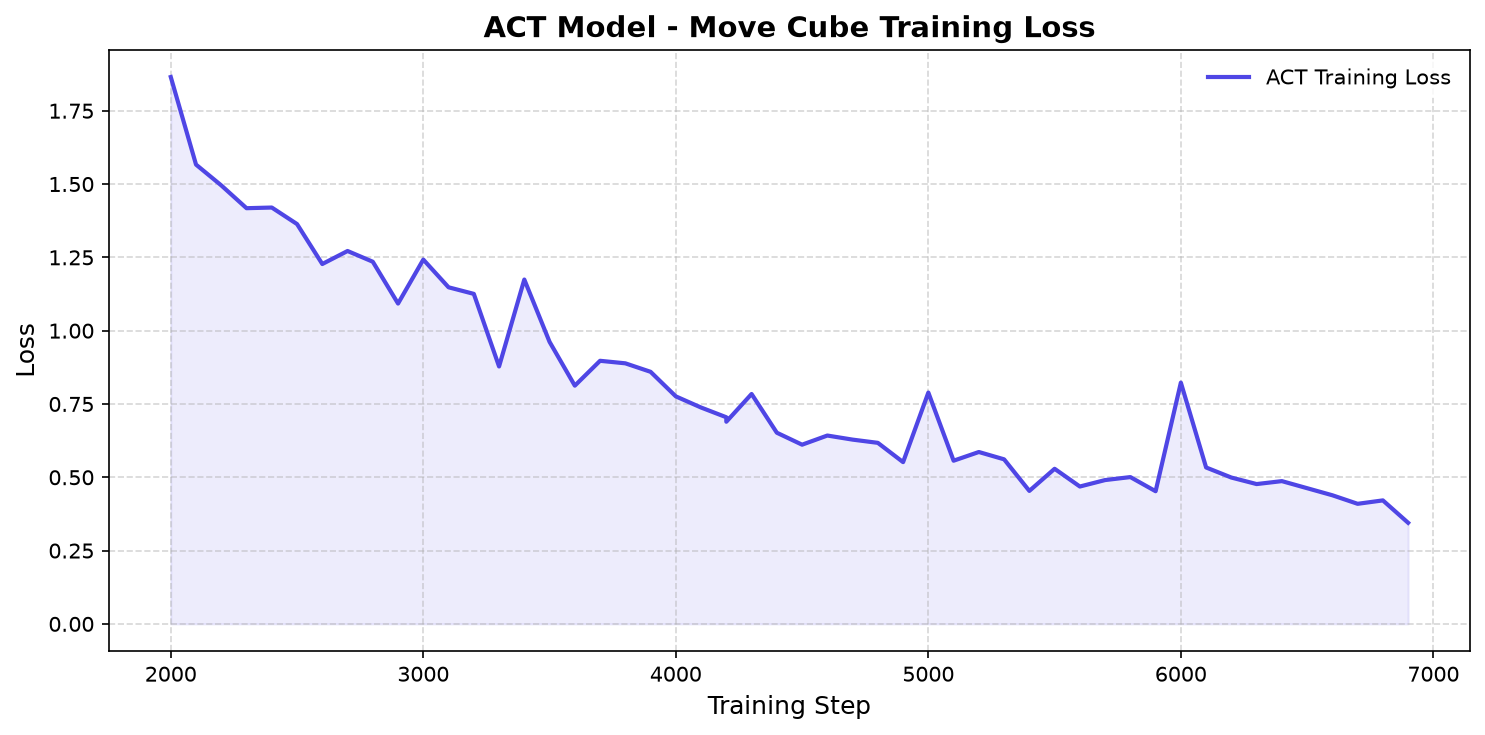

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your loss history file
history_path = Path("train/move_cube/loss_history.json")

if history_path.exists():
    with open(history_path, "r") as f:
        history = json.load(f)
    
    # Extract training loss (always present)
    train_steps = [entry["step"] for entry in history]
    train_losses = [entry["loss"] for entry in history]
    
    # Extract validation loss (only present at validation steps)
    val_steps = [entry["step"] for entry in history if "val_loss" in entry]
    val_losses = [entry["val_loss"] for entry in history if "val_loss" in entry]
    
    # Create the plot
    plt.figure(figsize=(10, 5), dpi=120)
    
    # 1. Plot Training Loss
    plt.plot(train_steps, train_losses, label="Training Loss", color="#4f46e5", linewidth=2)
    plt.fill_between(train_steps, train_losses, color="#4f46e5", alpha=0.08)
    
    # 2. Plot Validation Loss (if any exists)
    if val_losses:
        plt.plot(
            val_steps, 
            val_losses, 
            label="Validation Loss", 
            color="#ef4444", 
            linewidth=2, 
            marker='o', 
            markersize=5, 
            markerfacecolor="#b91c1c"
        )
        plt.fill_between(val_steps, val_losses, color="#ef4444", alpha=0.05)
    else:
        print("Note: No validation loss entries found in the history file yet.")
    
    # Formatting
    plt.xlabel("Training Step", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.title("ACT Model - Move Cube Metrics", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=True, facecolor="white", edgecolor="none")
    plt.tight_layout()
    plt.show()
else:
    print(f"No loss history found at {history_path}. Run a training session first to generate it!")


## 배포!

In [ ]:
from lerobot.cameras.opencv import OpenCVCameraConfig
from lerobot.policies import ACTConfig
from lerobot.configs import PreTrainedConfig
from rollout import rollout

if 'robot' in globals() and robot is not None and robot.is_connected:
    robot.disconnect()

# Configure robot for rollout with the same cameras, resolution, and MJPG codec
rollout_cam_resolution = (640, 480)

left_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_1",
    fps=30,
    width=rollout_cam_resolution[0],
    height=rollout_cam_resolution[1],
    fourcc="MJPG",
)
right_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_2",
    fps=30,
    width=rollout_cam_resolution[0],
    height=rollout_cam_resolution[1],
    fourcc="MJPG",
)
top_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_top",
    fps=30,
    width=rollout_cam_resolution[0],
    height=rollout_cam_resolution[1],
    fourcc="MJPG",
)

left_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_1",
    cameras={"cam": left_cam_config},
)
right_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_2",
    cameras={"cam": right_cam_config},
)

robot_with_cam_config = BiSOFollowerConfig(
    id="lhwdev_follower3",
    left_arm_config=left_follower_config,
    right_arm_config=right_follower_config,
    cameras={"top": top_cam_config},
)

pretrained_path = Path("./train/move_cube") / "checkpoints" / "last"
policy_config = PreTrainedConfig.from_pretrained(pretrained_path, local_files_only=True)
policy_config.pretrained_path = pretrained_path

rollout(robot_with_cam_config, policy_config, "Pick the blue cube, and put in red dish.", 20.0, asynchronous=False, compile=True)

INFO 2026-06-29 17:25:07 /context.py:177 Loading policy from 'train/move_cube/checkpoints/last'...


Loading weights from local directory


INFO 2026-06-29 17:25:07 /context.py:209 Policy loaded: type=act, device=xpu
INFO 2026-06-29 17:25:07 /context.py:219 torch.compile applied to predict_action_chunk
INFO 2026-06-29 17:25:07 /context.py:235 Connecting robot (so100_follower)...
WARNING 2026-06-29 17:25:07 a_opencv.py:292 OpenCVCamera(/dev/video3) does not natively support requested resolution 160x120. Capturing at native 640x360 and resizing via software.
INFO 2026-06-29 17:25:08 a_opencv.py:182 OpenCVCamera(/dev/video3) connected.
INFO 2026-06-29 17:25:08 follower.py:105 lhwdev_follower3 SOFollower connected.
INFO 2026-06-29 17:25:08 /context.py:238 Robot connected: so_follower
INFO 2026-06-29 17:25:08 /context.py:243 Captured initial robot position (6 keys)
INFO 2026-06-29 17:25:08 /context.py:407 Creating inference engine (type=rtc)...
INFO 2026-06-29 17:25:08 /factory.py:100 Creating inference engine: rtc
INFO 2026-06-29 17:25:08 ence/rtc.py:136 RTCInferenceEngine initialized (torch.compile enabled, 2 warmup inference

Shutting down and cleaning up strategy...


INFO 2026-06-29 17:35:27 ies/core.py:133 Disconnecting robot...
INFO 2026-06-29 17:35:27 a_opencv.py:616 OpenCVCamera(/dev/video3) disconnected.
INFO 2026-06-29 17:35:27 follower.py:229 lhwdev_follower3 SOFollower disconnected.
INFO 2026-06-29 17:35:27 gies/base.py:85 Base strategy teardown complete


Rollout finished successfully


In [ ]:
!lerobot-rollout \
    --strategy.type=base \
    --robot.type=bi_so_follower \
    --robot.id=lhwdev_follower3 \
    --robot.left_arm_config.port=/dev/lerobot/follower_1 \
    --robot.right_arm_config.port=/dev/lerobot/follower_2 \
    --robot.cameras='{top: {type: opencv, index_or_path: /dev/lerobot/camera_top, width: 640, height: 480, fps: 30}}' \
    --robot.left_arm_config.cameras='{cam: {type: opencv, index_or_path: /dev/lerobot/camera_1, width: 640, height: 480, fps: 30}}' \
    --robot.right_arm_config.cameras='{cam: {type: opencv, index_or_path: /dev/lerobot/camera_2, width: 640, height: 480, fps: 30}}' \
    --policy.path='./train/move_cube/checkpoints/last' \
    --task='Pick the blue cube, and put in red dish.' \
    --fps=10

In [ ]:
!python ../../src/lerobot/scripts/control_robot.py \
    --robot.type=bi_so_follower \
    --robot.left_arm_config.port=/dev/lerobot/follower_1 \
    --robot.right_arm_config.port=/dev/lerobot/follower_2 \
    --robot.id=lhwdev_follower3 \
    --control.fps=30 \
    --control.policy.path='train/pick_umbrella3'

python: can't open file '/home/lhwdev/csi-agent/lerobot/lhwdev/../scripts/control_robot.py': [Errno 2] No such file or directory


In [ ]:
!lerobot-train \
    --dataset.repo_id='lhwdev/move_cube' \
    --dataset.root='/home/lhwdev/csi-agent/lerobot/lhwdev/records/move_cube' \
    --output_dir='train/move_cube_smolvla' \
    --policy.path=lerobot/smolvla_base \
    --policy.device=xpu \
    --policy.push_to_hub=false \
    --policy.output_features=null \
    --policy.input_features=null \
    --policy.optimizer_lr=1e-3 \
    --policy.scheduler_decay_lr=1e-4 \
    --peft.method_type=LORA \
    --peft.r=64 \
    --steps=100 \
    --batch_size=32

/bin/bash: /home/lhwdev/miniconda3/envs/lerobot/lib/libtinfo.so.6: no version information available (required by /bin/bash)
INFO 2026-06-26 17:15:09 ot_train.py:221 {'batch_size': 32,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataset': {'episodes': None,
             'image_transforms': {'enable': False,
                                  'max_num_transforms': 3,
                                  'random_order': False,
                                  'tfs': {'affine': {'kwargs': {'degrees': [-5.0,
                                                                            5.0],
                                                                'translate': [0.05,
                                                                              0.05]},
                                                     'type': 'RandomAffine',
                                                     'weight': 1.0},
                                          'brightness': {'kwargs': {'brightness':